In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2022-12-26
Revised on 2026-03-31

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Histograms, Kernel Density Estimation (KDE), and Rug Plots
===========================================================

Description:
    Demonstrates how to combine histograms, KDE curves, and rug plots
    into a single visualization using matplotlib and seaborn. Loads
    FIFA player data from a CSV and plots distributions for age,
    height, weight, and wage in a 1x4 subplot grid.

    Techniques demonstrated:
        - pd.read_csv() with selective column loading (usecols)
        - ax.hist() with density=True for probability density histograms
        - sns.kdeplot() overlaid on histogram axes
        - sns.rugplot() for individual observation markers
        - Iterative subplot generation with enumerate()

    Input file: ../data/fifa_cleaned.csv
        Source: https://www.kaggle.com/datasets/rishidamarla/fifa-players-ratings
        Variables plotted: age, height_cm, weight_kgs, wage_euro

References:
    - Pandas General Functions (accessed Feb. 20, 2022):
      https://pandas.pydata.org/pandas-docs/stable/reference/general_functions.html
    - Seaborn Statistical Data Visualization (accessed Dec. 29, 2022):
      https://seaborn.pydata.org/

Revision History:
    2022-12-26  Original development
                - Histogram + KDE + rug plot loop across 4 FIFA variables
                - 1x4 subplot grid with matplotlib and seaborn

    2026-03-31  Revision
                - Added module-level docstring (Cell [1])
                - Updated environment to Python 3.14.3 / myenv / M5
                - Noted duplicate pandas import (cosmetic)
"""

'\nCreated on 2022-12-26\nRevised on 2026-03-31\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nHistograms, Kernel Density Estimation (KDE), and Rug Plots\n===========================================================\n\nDescription:\n    Demonstrates how to combine histograms, KDE curves, and rug plots\n    into a single visualization using matplotlib and seaborn. Loads\n    FIFA player data from a CSV and plots distributions for age,\n    height, weight, and wage in a 1x4 subplot grid.\n\n    Techniques demonstrated:\n        - pd.read_csv() with selective column loading (usecols)\n        - ax.hist() with density=True for probability density histograms\n        - sns.kdeplot() overlaid on histogram axes\n        - sns.rugplot() for individual observation markers\n        - Iterative s

# Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Load data from a csv

In [3]:
# https://www.kaggle.com/datasets/rishidamarla/fifa-players-ratings
# And specify which columns to load
df = pd.read_csv('../data/fifa_cleaned.csv', usecols = ['id', 'name', 'birth_date', 'age',
                                                'height_cm', 'weight_kgs', 'positions',
                                                'club_team', 'national_team', 'overall_rating',
                                                'wage_euro'])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              17954 non-null  int64  
 1   name            17954 non-null  str    
 2   birth_date      17954 non-null  str    
 3   age             17954 non-null  int64  
 4   height_cm       17954 non-null  float64
 5   weight_kgs      17954 non-null  float64
 6   positions       17954 non-null  str    
 7   overall_rating  17954 non-null  int64  
 8   wage_euro       17708 non-null  float64
 9   club_team       17940 non-null  str    
 10  national_team   857 non-null    str    
dtypes: float64(3), int64(3), str(5)
memory usage: 1.5 MB


# KDE plots

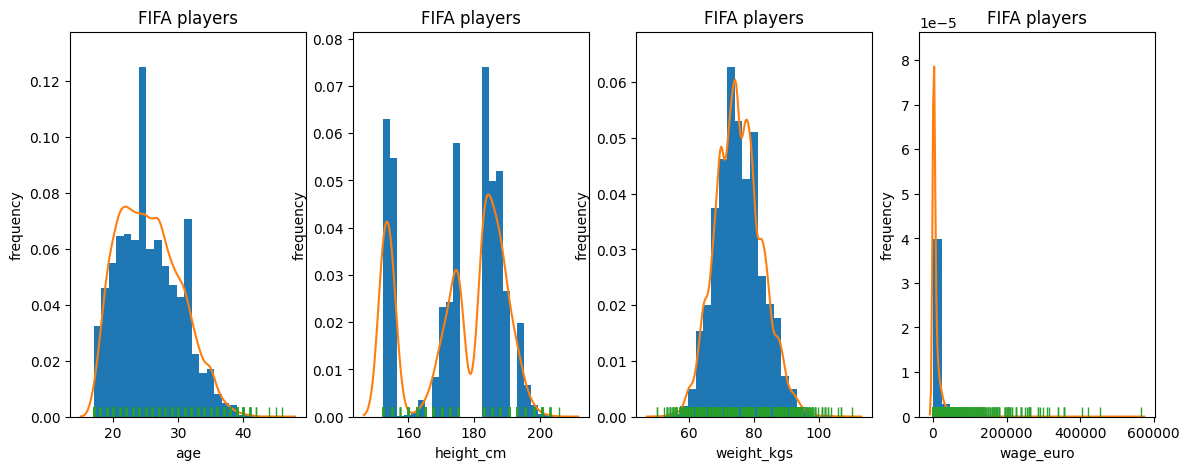

In [5]:
vars = ['age', 'height_cm', 'weight_kgs', 'wage_euro']

fig, ax = plt.subplots(1, 4, figsize=(14,5))
ax = ax.flatten()

# Loop through variables
# We have one single lambda
for i, var in enumerate(vars):
    # title = str(bt)
    # Plote once
    ax[i].hist(df[var], bins=25, density=True)
    sns.kdeplot(x=df[var], ax=ax[i])
    sns.rugplot(x=df[var], ax=ax[i])
    ax[i].set_ylabel('frequency')
    ax[i].set_xlabel(var)
    ax[i].set_title('FIFA players')
